# Reeling in Smart Attackers' Phishing Emails — Colab notebook

**CSE 587 — Group 5**: Parker Davis · Dillon VanGilder · Emmanuel Adjei Domfeh.

End-to-end pipeline:
1. Install dependencies
2. Clone the project from GitHub
3. (Optional) Mount Google Drive to back up checkpoints
4. Download the Champa et al. curated phishing dataset
5. Train BERT baseline
6. Train **with smart-attacker augmentation**
7. Compare the two stages + per-edit ablation

Runtime: **A100 GPU** (Runtime → Change runtime type → A100 GPU). Falls back to T4/V100 automatically if A100 isn't available — the train script uses bfloat16 on A100/H100 and fp16+GradScaler on older GPUs.

## 1. Install dependencies

In [1]:
!pip install -q transformers==4.45.2 datasets==2.21.0 accelerate==0.34.2 \
    scikit-learn pandas matplotlib seaborn nltk requests pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 70.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


## 2. Clone the project from GitHub

The repo is public, so HTTPS clone works without auth.

In [2]:
!git clone https://github.com/eadomfeh1/cse587-phishing.git
%cd cse587-phishing

Cloning into 'cse587-phishing'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 34 (delta 4), reused 34 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 268.58 KiB | 11.68 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/cse587-phishing


In [3]:
import os, sys
sys.path.insert(0, os.getcwd())
print('CWD:', os.getcwd())
print('Files:', sorted(os.listdir('.')))

CWD: /content/cse587-phishing
Files: ['.git', '.gitignore', 'README.md', 'manuscript', 'notebooks', 'requirements.txt', 'scripts', 'src']


## 2b. (Optional) Back up results to Google Drive

Colab runtimes disconnect after a while and lose `/content`. Mounting Drive lets us copy `results/` somewhere persistent at the end of each run. Skip this cell if you'd rather just download the JSON manually.

In [4]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/cse587_results', exist_ok=True)

Mounted at /content/drive


## 3. Download the dataset (Champa et al. 2024)

In [5]:
!python scripts/download_data.py
!ls -lh data/raw

Querying figshare metadata: https://api.figshare.com/v2/articles/24899952
  ↓ CEAS_08.csv from https://ndownloader.figshare.com/files/43817124
  ↓ Enron.csv from https://ndownloader.figshare.com/files/43817121
  ↓ Ling.csv from https://ndownloader.figshare.com/files/43817115
  ↓ SpamAssasin.csv from https://ndownloader.figshare.com/files/43817118
  ↓ TREC_05.csv from https://ndownloader.figshare.com/files/43817130
  ↓ TREC_06.csv from https://ndownloader.figshare.com/files/43817127
  ↓ TREC_07.csv from https://ndownloader.figshare.com/files/43817133
  ↓ Ceas-08_vectorized_data.csv from https://ndownloader.figshare.com/files/43826865
  ↓ Enron_vectorized_data.csv from https://ndownloader.figshare.com/files/43826862
  ↓ Ling_vectorized_data.csv from https://ndownloader.figshare.com/files/43826859
  ↓ SpamAssasin_vectorized_data.csv from https://ndownloader.figshare.com/files/43826856
  ↓ TREC-05_vectorized_data.csv from https://ndownloader.figshare.com/files/43826871
  ↓ TREC-06_vectoriz

## 4. Inspect the dataset

In [6]:
from src.data_loader import load_raw_csvs
df = load_raw_csvs()
print('Total rows:', len(df))
print(df.label.value_counts())
df.head(3)

Total rows: 131171
label
1    67230
0    63941
Name: count, dtype: int64


,subject,body,label,source
0,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,CEAS_08
1,Befriend Jenna Jameson,Upgrade your sex and pleasures with these tech...,1,CEAS_08
2,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,CEAS_08


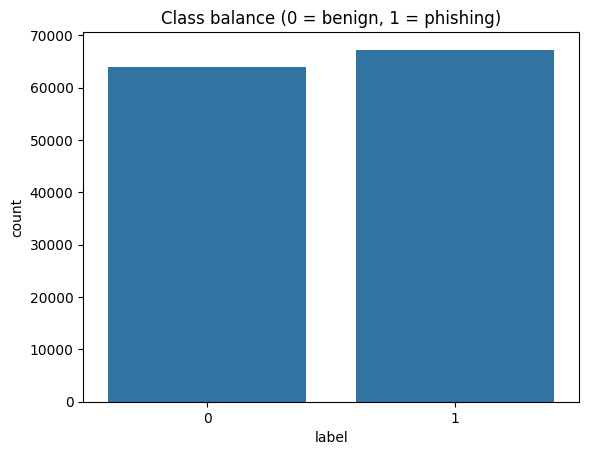

In [7]:
import seaborn as sns, matplotlib.pyplot as plt
sns.countplot(x='label', data=df)
plt.title('Class balance (0 = benign, 1 = phishing)')
plt.show()

## 5. Train baseline BERT (A100, batch 64, bfloat16)

In [8]:
# A100: batch 64 fits comfortably in 40GB VRAM with bfloat16 autocast.
# If you're on T4 (16GB), reduce to --batch_size 16.
!python -m src.train --model bert-base-uncased --epochs 3 --batch_size 64

2026-04-27 10:36:51,115 [INFO] __main__: Device: cuda | model: bert-base-uncased | epochs=3 | bs=64 | lr=2e-05
2026-04-27 10:36:52,483 [WARNING] src.data_loader: Skipping Ceas-08_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 10:36:53,300 [WARNING] src.data_loader: Skipping Enron_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 10:36:53,421 [WARNING] src.data_loader: Skipping Ling_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 10:36:53,647 [WARNING] src.data_loader: Skipping SpamAssasin_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 10:36:54,444 [WARNING] src.data_loader: Skipping TREC-05_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 10:36:54,680 [WARNING] src.data_loader: Skipping TREC-06_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 10:36:55,

In [9]:
# Back up baseline results to Drive (skip if you didn't mount Drive)
!cp -r results /content/drive/MyDrive/cse587_results/baseline_$(date +%Y%m%d_%H%M%S) 2>/dev/null && echo 'baseline saved to Drive' || echo 'Drive not mounted — skipping backup'

baseline saved to Drive


## 6. Train with smart-attacker augmentation

In [10]:
!python -m src.train --model bert-base-uncased --epochs 3 --augment --augment_factor 1 --batch_size 64

2026-04-27 10:53:27,124 [INFO] __main__: Device: cuda | model: bert-base-uncased | epochs=3 | bs=64 | lr=2e-05
2026-04-27 10:53:27,125 [INFO] __main__: Reusing cached splits in /content/cse587-phishing/data/processed
2026-04-27 10:54:36,643 [INFO] __main__: Augmented training set: 104936 -> 158720 rows
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/content/cse587-phishing/src/train.py:140: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
2026-04-27 10:55:36,586 [INFO] __main__: Mixed precision enabled: bfloat16
/content/cse587-phishing/src/train.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is depre

In [11]:
!cp -r results /content/drive/MyDrive/cse587_results/augmented_$(date +%Y%m%d_%H%M%S) 2>/dev/null && echo 'augmented saved to Drive' || echo 'Drive not mounted — skipping backup'

augmented saved to Drive


## 7. Compare reports

In [12]:
import json
from pathlib import Path
ra = json.loads(Path('results/eval_report.json').read_text())
ra

{'standard': {'accuracy': 0.995426132032322,
  'precision_phish': 0.9939214232765011,
  'recall_phish': 0.9971738807080173,
  'f1_phish': 0.9955449955449955,
  'macro_f1': 0.9954228737123474,
  'confusion_matrix': [[6354, 41], [19, 6704]],
  'roc_auc': 0.9997480321773585},
 'smart_attacker': {'accuracy': 0.9964171367586523,
  'precision_phish': 0.9939331163065996,
  'recall_phish': 0.9991075412762159,
  'f1_phish': 0.9965136117498702,
  'macro_f1': 0.9964143911356171,
  'confusion_matrix': [[6354, 41], [6, 6717]],
  'roc_auc': 0.9999232676223675},
 'ablation': {'mask_urls': {'accuracy': 0.9958072876962951,
   'precision_phish': 0.9939259259259259,
   'recall_phish': 0.9979175963111706,
   'f1_phish': 0.9959177614488236,
   'macro_f1': 0.9958042148934942,
   'confusion_matrix': [[6354, 41], [14, 6709]],
   'roc_auc': 0.9998637122259052},
  'remove_urgency': {'accuracy': 0.9956548254307059,
   'precision_phish': 0.9939241256668643,
   'recall_phish': 0.9976201100699092,
   'f1_phish': 0.

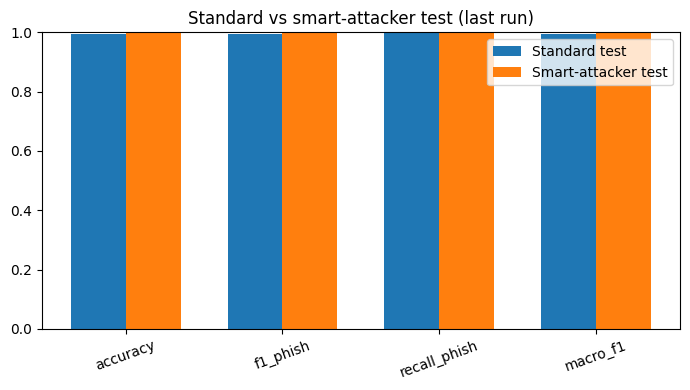

In [13]:
import matplotlib.pyplot as plt
labels = ['accuracy', 'f1_phish', 'recall_phish', 'macro_f1']
std = [ra['standard'][k] for k in labels]
sm  = [ra['smart_attacker'][k] for k in labels]
x = range(len(labels))
fig, ax = plt.subplots(figsize=(7, 4))
w = 0.35
ax.bar([i - w/2 for i in x], std, w, label='Standard test')
ax.bar([i + w/2 for i in x], sm,  w, label='Smart-attacker test')
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=20)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Standard vs smart-attacker test (last run)')
plt.tight_layout(); plt.show()

## 8. Per-edit ablation

How much does each individual smart-attacker edit hurt the model?

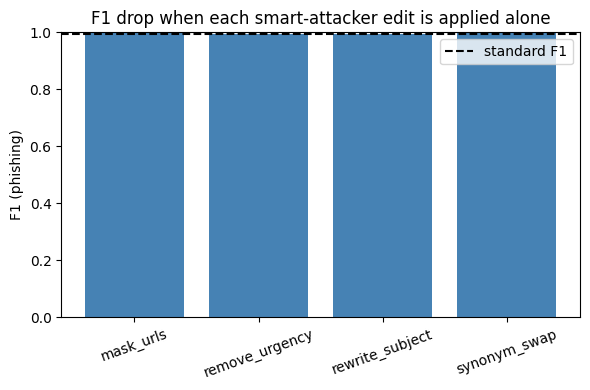

In [14]:
abl = ra['ablation']
ops = list(abl.keys())
f1s = [abl[o]['f1_phish'] for o in ops]
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(ops, f1s, color='steelblue')
ax.axhline(ra['standard']['f1_phish'], color='black', linestyle='--', label='standard F1')
ax.set_ylim(0, 1); ax.set_ylabel('F1 (phishing)')
ax.set_title('F1 drop when each smart-attacker edit is applied alone')
plt.xticks(rotation=20); plt.legend(); plt.tight_layout(); plt.show()

## 9. Inspect a few smart-attacker examples

In [15]:
from src.augmentation import AugmentationConfig, make_smart_attacker_eval
from src.data_loader import load_splits
splits = load_splits()
smart = make_smart_attacker_eval(splits['test'].head(20).copy(), AugmentationConfig())
for _, row in smart[smart.label == 1].head(3).iterrows():
    print('---')
    print(row['text'][:600])

---
Subject: Psychologist indorse products for men Smell better with among the girls with a stronger pheromone emitting rod of pleasure. [LINK] -- Using Opera's revolutionary e-mail guest: [Join]
---
Subject: Much bigger, than you secondhand to have it! Success favors only real men with huge-dimensioned rods... Become one of them! Many masses have already benefited from our method! You're the next! [LINK] minutes, and Enzo Maresca converted the chance to tieDefending the arrests, President Yoweri Museveni saidmain parties were also elect: Mark Durkan of the SDLP
---
Subject: [LINK] Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from [LINK] >Top videos and stories as of: Aug 1, 2008 3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= TOP 10 VIDEOS 1. PARIS HILTON TAKES ON MCCAIN [LINK] Paris Hilton swings back at Republican presidential candidate John McCain. Kareen Wynter reports. 2. BIKINI BARISTA STAND CLOSED [LINK]